# Unsupervised HP search + multi-seed finals

Hyperparameters are selected by **held-out unsupervised metrics** (Bernoulli LL for LV / LV+$e$ / GNN / GNN$_e$; negated mean Jaccard cost for NTAC; negated row MSE for PCA). Ground-truth Hungarian / ARI / NMI are reported only on multi-seed final runs.

Expected artifacts from `run_experiments.py` / `launch_lightning_sweep.py`:
- `hp_results.csv`, `hp_best.json`
- `final_results.csv`, `final_summary.csv`

This notebook adapts to whichever methods are present (e.g. `pca`, `lv`, `lv_e`, `gnn`, `gnn_e`, `ntac`). Reference lines on the finals plot: random $K$-assignment baseline and theoretical Hungarian max ($n_{\mathrm{shared}}$).

Because the selection metrics differ in both meaning and scale across methods — held-out Bernoulli log-likelihood ($-6.5$ to $-1.4$) for LV / LV+$e$ / GNN, negated held-out row MSE ($\approx -54$) for PCA, negated mean Jaccard cost ($\approx -0.48$) for NTAC — `val_metric` is only ever plotted on **per-method axes**, never pooled. Only the ground-truth metrics (Hungarian / ARI / NMI) are comparable across methods. Seed budgets may also differ per method (the NTAC sweep completed 2 of 3 final seeds before the remote studio stopped).

Alongside the log-likelihood we read the calibration-invariant held-out edge AUC (`val_auc`, joined from the per-run `*_metrics.json`; undefined for PCA and NTAC) and the Spearman rank correlation between `val_metric` and `gt_hungarian`, which makes explicit whether unsupervised selection would have chosen the ground-truth-optimal configuration.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 120
PALETTE = {
    "pca": "#6c757d",
    "lv": "#e76f51",
    "lv_e": "#2a9d8f",
    "gnn": "#2a6f97",
    "gnn_e": "#264653",
    "ntac": "#bc6c25",
}
METHOD_ORDER = ["pca", "lv", "lv_e", "gnn", "gnn_e", "ntac"]


def methods_present(df: pd.DataFrame) -> list[str]:
    found = set(df["method"].unique())
    return [m for m in METHOD_ORDER if m in found] + sorted(found - set(METHOD_ORDER))

## 1. Hyperparameter search (unsupervised selection)

In [2]:
hp = pd.read_csv("hp_results.csv")
best = json.loads(Path("hp_best.json").read_text())


def attach_val_auc(df: pd.DataFrame) -> pd.DataFrame:
    """Join the calibration-invariant held-out AUC from the per-run metrics JSON.

    ``val_auc`` is written by the LV / LV+e / GNN trainers but is not part of the
    aggregated CSVs; PCA and NTAC leave it undefined.
    """
    auc = {
        p.name[: -len("_metrics.json")]: json.loads(p.read_text()).get("val_auc")
        for p in Path(".").glob("*_metrics.json")
    }
    df["val_auc"] = df["name"].map(auc)
    return df


hp = attach_val_auc(hp)
HP_COLS = [
    c
    for c in [
        "name", "method", "d", "lr", "likelihood", "bfs_frac", "target_updates",
        "d_e", "e_wd", "val_metric", "val_auc", "gt_hungarian", "gt_ari", "gt_nmi",
    ]
    if c in hp.columns
]
display(
    hp.sort_values(["method", "val_metric"], ascending=[True, False])
    .groupby("method")
    .head(5)[HP_COLS]
)
print("Selected by val_metric:")
display(pd.DataFrame([
    {"method": m, "name": v["name"], "val_metric": v["val_metric"], **v["hyperparams"]}
    for m, v in best.items()
]))

,name,method,d,lr,likelihood,bfs_frac,target_updates,d_e,e_wd,val_metric,val_auc,gt_hungarian,gt_ari,gt_nmi
0,hp_lv_d64_lr0.1_bfs1.0_bernoulli,lv,64,0.10,bernoulli,1.0,NaN,NaN,NaN,-2.273741,0.911955,7803.0,0.145974,0.506733
2,hp_lv_d64_lr0.1_bfs1.0_nb,lv,64,0.10,nb,1.0,NaN,NaN,NaN,-2.275300,0.906772,8115.0,0.148631,0.474042
5,hp_lv_d128_lr0.1_bfs1.0_nb,lv,128,0.10,nb,1.0,NaN,NaN,NaN,-2.386568,0.888238,8340.0,0.237113,0.437628
8,hp_lv_d256_lr0.1_bfs1.0_nb,lv,256,0.10,nb,1.0,NaN,NaN,NaN,-2.583733,0.847113,5722.0,0.090908,0.339089
9,hp_lv_control_d64_lr0.1_bernoulli,lv,64,0.10,bernoulli,0.0,3390.0,NaN,NaN,-3.816151,0.801347,2578.0,0.056594,0.237813
11,hp_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_poisson,lv_e,64,0.05,poisson,1.0,NaN,16.0,0.01,-1.397446,0.982913,5047.0,0.042605,0.365572
12,hp_lv_e_d128_de16_lr0.05_ewd0.01_bfs1.0_bernoulli,lv_e,128,0.05,bernoulli,1.0,NaN,16.0,0.01,-1.405054,0.985066,4503.0,0.028598,0.344418
10,hp_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_bernoulli,lv_e,64,0.05,bernoulli,1.0,NaN,16.0,0.01,-1.418565,0.985135,4551.0,0.032480,0.354812
13,hp_lv_e_d128_de16_lr0.05_ewd0.01_bfs1.0_poisson,lv_e,128,0.05,poisson,1.0,NaN,16.0,0.01,-1.427217,0.983860,4780.0,0.041739,0.363780
16,hp_ntac_k729_R12_T0.1,ntac,729,0.00,NaN,NaN,NaN,NaN,NaN,-0.480313,NaN,30672.0,0.679849,0.879501


Selected by val_metric:


,method,name,val_metric,d,lr,bfs_frac,likelihood,d_e,e_wd,max_k,max_iterations,frac_seeds
0,lv,hp_lv_d64_lr0.1_bfs1.0_bernoulli,-2.273741,64,0.10,1.0,bernoulli,NaN,NaN,NaN,NaN,NaN
1,lv_e,hp_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_poisson,-1.397446,64,0.05,1.0,poisson,16.0,0.01,NaN,NaN,NaN
2,ntac,hp_ntac_k729_R12_T0.1,-0.480313,729,0.00,NaN,NaN,NaN,NaN,729.0,12.0,0.1
3,pca,hp_pca_d32_lr0.01,-53.905715,32,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN


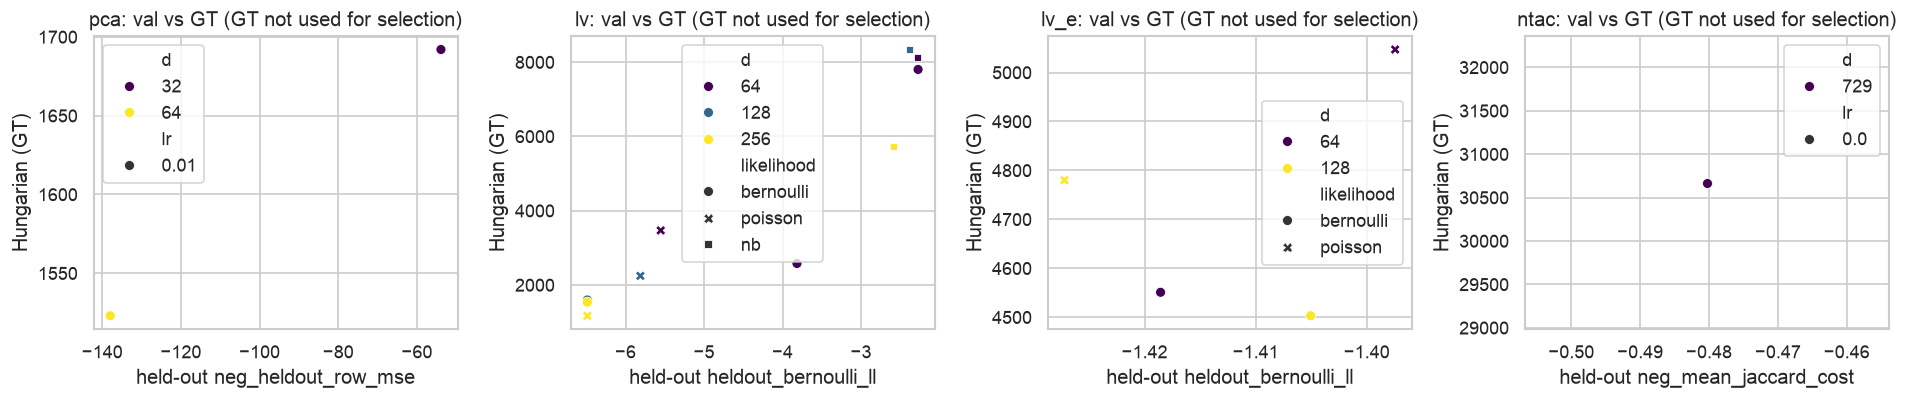

Selection metric per method (not comparable across methods):
  pca: neg_heldout_row_mse in [-137.9724, -53.9057] over 2 configuration(s)
  lv: heldout_bernoulli_ll in [-6.4864, -2.2737] over 10 configuration(s)
  lv_e: heldout_bernoulli_ll in [-1.4272, -1.3974] over 4 configuration(s)
  ntac: neg_mean_jaccard_cost in [-0.4803, -0.4803] over 1 configuration(s)
Spearman rho(val_metric, gt_hungarian) — selection/ground-truth agreement:
  pca: too few configurations (2) for a rank correlation
  lv: rho=+0.936 over 10 config(s); argmax DISAGREE
      val-best: hp_lv_d64_lr0.1_bfs1.0_bernoulli
      GT-best : hp_lv_d128_lr0.1_bfs1.0_nb
  lv_e: rho=+0.200 over 4 config(s); argmax agree
  ntac: too few configurations (1) for a rank correlation


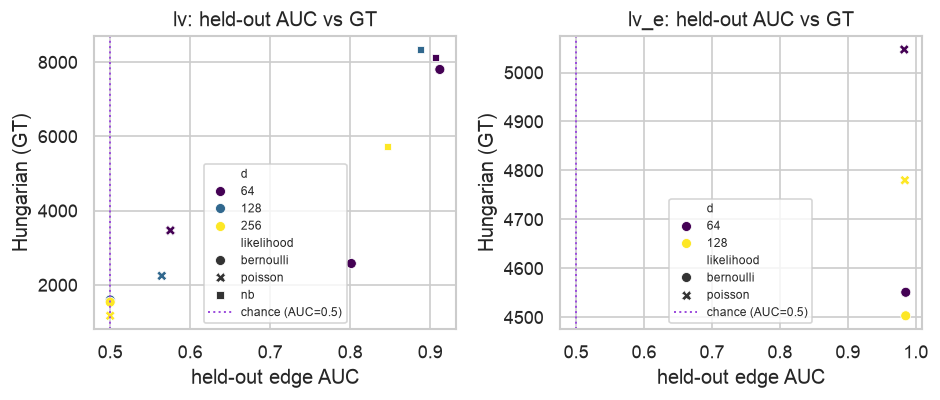

Matched-compute bfs_frac=0 control(s):


,name,method,d,lr,likelihood,bfs_frac,target_updates,d_e,e_wd,val_metric,val_auc,gt_hungarian,gt_ari,gt_nmi
9,hp_lv_control_d64_lr0.1_bernoulli,lv,64,0.1,bernoulli,0.0,3390.0,NaN,NaN,-3.816151,0.801347,2578.0,0.056594,0.237813


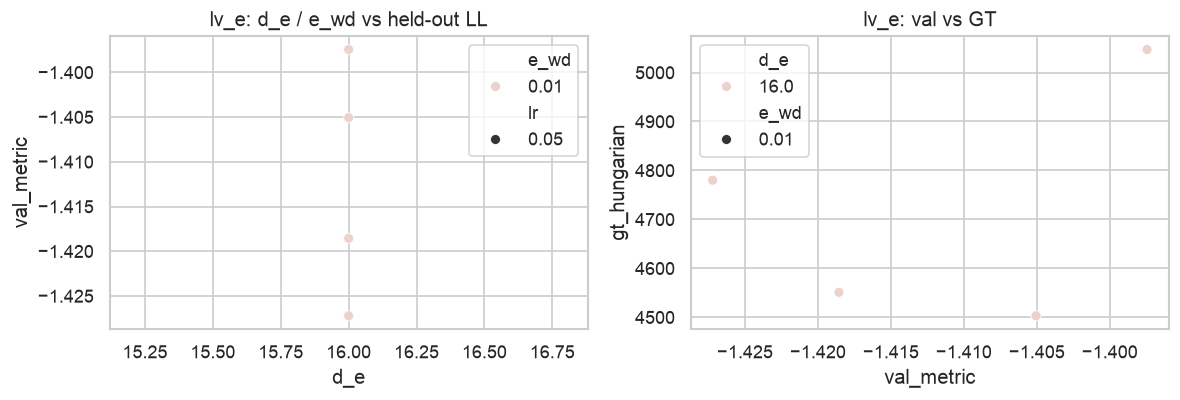

In [3]:
# `val_metric` is method-specific (Bernoulli LL, negated row MSE, negated mean
# Jaccard cost), so every method gets its own x-axis: values are NOT comparable
# across panels and must never be pooled on a shared axis.
methods = methods_present(hp)
metric_names = hp.groupby("method")["val_metric_name"].first().to_dict()
n = max(len(methods), 1)
fig, axes = plt.subplots(1, n, figsize=(4.0 * n, 3.5), sharex=False, sharey=False)
if n == 1:
    axes = [axes]
for ax, method in zip(axes, methods):
    sub = hp[hp["method"] == method].copy()
    # Likelihood is the more informative second channel wherever it is defined
    # (LV / LV+e / GNN); PCA and NTAC fall back to the learning rate.
    style_col = "likelihood" if sub.get("likelihood", pd.Series(dtype=object)).notna().any() else "lr"
    sns.scatterplot(
        data=sub, x="val_metric", y="gt_hungarian",
        hue="d", style=style_col, ax=ax, palette="viridis",
    )
    ax.set_title(f"{method}: val vs GT (GT not used for selection)")
    ax.set_xlabel(f"held-out {metric_names.get(method, 'val_metric')}")
    ax.set_ylabel("Hungarian (GT)")
plt.tight_layout()
plt.show()

print("Selection metric per method (not comparable across methods):")
for method in methods:
    sub = hp[hp["method"] == method]
    print(
        f"  {method}: {metric_names.get(method, 'val_metric')} "
        f"in [{sub['val_metric'].min():.4f}, {sub['val_metric'].max():.4f}] "
        f"over {len(sub)} configuration(s)"
    )

# Does the unsupervised selection metric rank configurations the way ground truth
# does? A low or negative rho means val_metric and Hungarian disagree, so the
# selected configuration need not be the ground-truth optimum.
print("Spearman rho(val_metric, gt_hungarian) — selection/ground-truth agreement:")
for method in methods:
    sub = hp[hp["method"] == method]
    if len(sub) > 2:
        rho = sub["val_metric"].corr(sub["gt_hungarian"], method="spearman")
        argmax_val = sub.loc[sub["val_metric"].idxmax(), "name"]
        argmax_gt = sub.loc[sub["gt_hungarian"].idxmax(), "name"]
        agree = "agree" if argmax_val == argmax_gt else "DISAGREE"
        print(f"  {method}: rho={rho:+.3f} over {len(sub)} config(s); argmax {agree}")
        if argmax_val != argmax_gt:
            print(f"      val-best: {argmax_val}\n      GT-best : {argmax_gt}")
    else:
        print(f"  {method}: too few configurations ({len(sub)}) for a rank correlation")

# Held-out AUC is calibration-invariant, so it separates "the model ranks edges
# well" from "the model is merely well-calibrated" (only defined for LV/LV+e/GNN).
if hp["val_auc"].notna().any():
    auc_methods = [m for m in methods if hp.loc[hp["method"] == m, "val_auc"].notna().any()]
    fig, axes = plt.subplots(1, len(auc_methods), figsize=(4.0 * len(auc_methods), 3.5))
    axes = np.atleast_1d(axes)
    for ax, method in zip(axes, auc_methods):
        sub = hp[(hp["method"] == method) & hp["val_auc"].notna()]
        style_col = "likelihood" if sub["likelihood"].notna().any() else "lr"
        sns.scatterplot(
            data=sub, x="val_auc", y="gt_hungarian",
            hue="d", style=style_col, ax=ax, palette="viridis",
        )
        ax.axvline(0.5, color="#9d4edd", ls=":", lw=1.2, label="chance (AUC=0.5)")
        ax.set_title(f"{method}: held-out AUC vs GT")
        ax.set_xlabel("held-out edge AUC")
        ax.set_ylabel("Hungarian (GT)")
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

# Matched-compute bfs_frac=0 controls, when the sweep included them.
if "bfs_frac" in hp.columns and (hp["bfs_frac"] == 0.0).any():
    print("Matched-compute bfs_frac=0 control(s):")
    display(hp[hp["bfs_frac"] == 0.0][HP_COLS])

# LV+e: residual dim / weight decay vs held-out LL (if present)
if "lv_e" in methods and {"d_e", "e_wd"}.issubset(hp.columns):
    sub = hp[hp["method"] == "lv_e"].copy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    sns.scatterplot(data=sub, x="d_e", y="val_metric", hue="e_wd", style="lr", ax=axes[0])
    axes[0].set_title("lv_e: d_e / e_wd vs held-out LL")
    axes[0].set_ylabel("val_metric")
    sns.scatterplot(data=sub, x="val_metric", y="gt_hungarian", hue="d_e", style="e_wd", ax=axes[1])
    axes[1].set_title("lv_e: val vs GT")
    plt.tight_layout()
    plt.show()

## 2. Multi-seed uncertainty (final runs)

In [4]:
from evaluate_clustering import (
    align_assignments,
    encode_labels,
    load_assignment_dict,
    load_ground_truth,
    random_assignment_baseline,
)

final = attach_val_auc(pd.read_csv("final_results.csv"))
summary = pd.read_csv("final_summary.csv")
display(summary)
display(final.sort_values(["method", "seed"])[[c for c in HP_COLS if c in final.columns] + ["seed"]])

# Random baseline + theoretical max on the same shared GT set as the finals.
gt = load_ground_truth(Path("root_id_type_dict.pkl"))
pred_paths = sorted(Path(".").glob("final_*_assignment_dict*.npy"))
if pred_paths:
    pred0 = load_assignment_dict(pred_paths[0])
    gt_labels, _, shared = align_assignments(pred0, gt)
else:
    gt_labels, _ = encode_labels(list(gt.values()))
    shared = list(gt.keys())

k_pred = 729
rand_base = random_assignment_baseline(gt_labels, k=k_pred, n_seeds=20, seed=0)
print(
    f"Random (K={k_pred}, n={len(shared)}, 20 seeds): "
    f"Hungarian {rand_base['hungarian_mean']:.1f} ± {rand_base['hungarian_std']:.1f} "
    f"| ARI {rand_base['ari_mean']:.4f} ± {rand_base['ari_std']:.4f} "
    f"| NMI {rand_base['nmi_mean']:.4f} ± {rand_base['nmi_std']:.4f}"
)
print(
    f"Theoretical max (perfect recovery): Hungarian {rand_base['hungarian_max']:.0f}, "
    f"ARI {rand_base['ari_max']:.0f}, NMI {rand_base['nmi_max']:.0f}"
)

,ari_mean,ari_std,hp_bfs_frac,hp_d,hp_d_e,hp_e_wd,hp_frac_seeds,hp_likelihood,hp_lr,hp_max_iterations,hp_max_k,hungarian_mean,hungarian_std,method,n_seeds,nmi_mean,nmi_std,selection_val_metric
0,0.176534,0.020259,1.0,64,NaN,NaN,NaN,bernoulli,0.10,NaN,NaN,8459.666667,354.079558,lv,3,0.509301,0.017612,-2.273741
1,0.041721,0.002472,1.0,64,16.0,0.01,NaN,poisson,0.05,NaN,NaN,5216.333333,89.198281,lv_e,3,0.372948,0.001916,-1.397446
2,0.675656,0.005929,NaN,729,NaN,NaN,0.1,NaN,0.00,12.0,729.0,30654.500000,24.748737,ntac,2,0.878414,0.001537,-0.480313
3,0.008135,0.002646,NaN,32,NaN,NaN,NaN,NaN,0.01,NaN,NaN,1355.000000,88.831301,pca,3,0.224727,0.008043,-53.905715


,name,method,d,lr,likelihood,bfs_frac,d_e,e_wd,val_metric,val_auc,gt_hungarian,gt_ari,gt_nmi,seed
0,final_lv_d64_lr0.1_bfs1.0_bernoulli_seed0,lv,64,0.10,bernoulli,1.0,NaN,NaN,-6.138501,0.536961,8451.0,0.159746,0.524126,0
1,final_lv_d64_lr0.1_bfs1.0_bernoulli_seed1,lv,64,0.10,bernoulli,1.0,NaN,NaN,-6.026716,0.546459,8818.0,0.199037,0.513944,1
2,final_lv_d64_lr0.1_bfs1.0_bernoulli_seed2,lv,64,0.10,bernoulli,1.0,NaN,NaN,-6.061628,0.547589,8110.0,0.170820,0.489833,2
3,final_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_pois...,lv_e,64,0.05,poisson,1.0,16.0,0.01,-1.232121,0.992163,5144.0,0.038998,0.371004,0
4,final_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_pois...,lv_e,64,0.05,poisson,1.0,16.0,0.01,-1.194342,0.992594,5189.0,0.042341,0.374835,1
5,final_lv_e_d64_de16_lr0.05_ewd0.01_bfs1.0_pois...,lv_e,64,0.05,poisson,1.0,16.0,0.01,-1.219985,0.992179,5316.0,0.043823,0.373006,2
9,final_ntac_k729_R12_T0.1_seed0,ntac,729,0.00,NaN,NaN,NaN,NaN,-0.480313,NaN,30672.0,0.679849,0.879501,0
10,final_ntac_k729_R12_T0.1_seed1,ntac,729,0.00,NaN,NaN,NaN,NaN,-0.482294,NaN,30637.0,0.671464,0.877327,1
6,final_pca_d32_lr0.01_seed0,pca,32,0.01,NaN,NaN,NaN,NaN,-1.480807,NaN,1369.0,0.009491,0.219383,0
7,final_pca_d32_lr0.01_seed1,pca,32,0.01,NaN,NaN,NaN,NaN,-5.363856,NaN,1436.0,0.009829,0.220821,1


Random (K=729, n=46479, 20 seeds): Hungarian 980.0 ± 8.0 | ARI 0.0000 ± 0.0000 | NMI 0.2015 ± 0.0003
Theoretical max (perfect recovery): Hungarian 46479, ARI 1, NMI 1


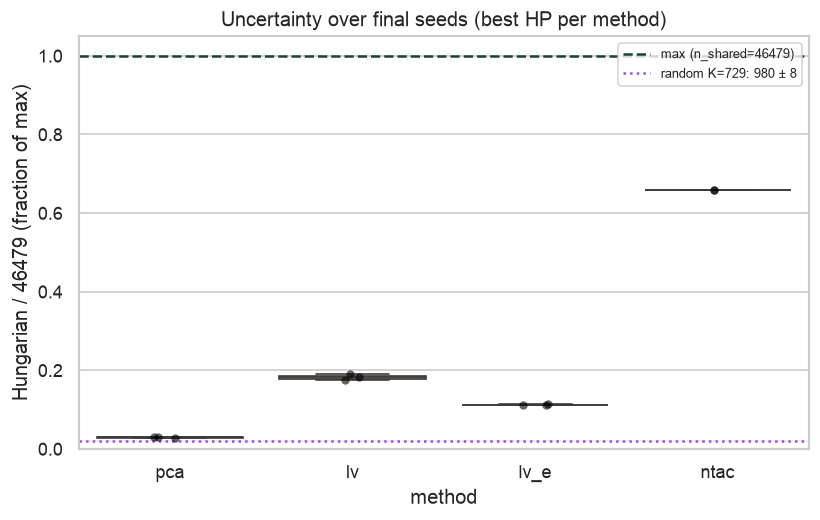

ntac (n_seeds=2): Hungarian 30654.5 ± 24.7 (65.95% of max); ARI 0.676 ± 0.006, NMI 0.878 ± 0.002
lv (n_seeds=3): Hungarian 8459.7 ± 354.1 (18.20% of max); ARI 0.177 ± 0.020, NMI 0.509 ± 0.018
lv_e (n_seeds=3): Hungarian 5216.3 ± 89.2 (11.22% of max); ARI 0.042 ± 0.002, NMI 0.373 ± 0.002
pca (n_seeds=3): Hungarian 1355.0 ± 88.8 (2.92% of max); ARI 0.008 ± 0.003, NMI 0.225 ± 0.008
note: seed budgets differ across methods ({'lv': 3, 'lv_e': 3, 'ntac': 2, 'pca': 3}); dispersion is not directly comparable
random: Hungarian 980.0 ± 8.0 (2.11% of max); ARI 0.000 ± 0.000, NMI 0.202 ± 0.000
max:    Hungarian 46479 (100%; ARI/NMI = 1)


In [5]:
# Plot as fraction of theoretical max so random + ceiling are on-scale.
n_shared = float(rand_base["hungarian_max"])
plot_df = final.copy()
plot_df["hungarian_frac"] = plot_df["gt_hungarian"] / n_shared
rand_frac = rand_base["hungarian_mean"] / n_shared
rand_frac_std = rand_base["hungarian_std"] / n_shared

fig, ax = plt.subplots(figsize=(7, 4.5))
order = methods_present(final)
palette = {m: PALETTE.get(m, "#333333") for m in order}
sns.boxplot(
    data=plot_df, x="method", y="hungarian_frac", order=order,
    hue="method", palette=palette, legend=False, ax=ax,
)
sns.stripplot(
    data=plot_df, x="method", y="hungarian_frac", order=order,
    color="black", alpha=0.6, ax=ax,
)
ax.axhline(1.0, color="#1b4332", ls="--", lw=1.5, label=f"max (n_shared={n_shared:.0f})")
ax.axhline(
    rand_frac,
    color="#9d4edd",
    ls=":",
    lw=1.5,
    label=f"random K={k_pred}: {rand_base['hungarian_mean']:.0f} ± {rand_base['hungarian_std']:.0f}",
)
ax.axhspan(
    rand_frac - rand_frac_std,
    rand_frac + rand_frac_std,
    color="#9d4edd",
    alpha=0.12,
    zorder=0,
)
ax.set_ylim(0, 1.05)
ax.set_ylabel(f"Hungarian / {n_shared:.0f} (fraction of max)")
ax.set_title("Uncertainty over final seeds (best HP per method)")
ax.legend(loc="upper right", fontsize=8, frameon=True)
plt.tight_layout()
plt.show()

for _, row in summary.sort_values("hungarian_mean", ascending=False).iterrows():
    print(
        f"{row['method']} (n_seeds={int(row['n_seeds'])}): "
        f"Hungarian {row['hungarian_mean']:.1f} ± {row['hungarian_std']:.1f} "
        f"({100 * row['hungarian_mean'] / n_shared:.2f}% of max); "
        f"ARI {row['ari_mean']:.3f} ± {row['ari_std']:.3f}, "
        f"NMI {row['nmi_mean']:.3f} ± {row['nmi_std']:.3f}"
    )
n_seed_counts = summary.set_index("method")["n_seeds"].astype(int).to_dict()
if len(set(n_seed_counts.values())) > 1:
    print(
        f"note: seed budgets differ across methods ({n_seed_counts}); "
        "dispersion is not directly comparable"
    )
print(
    f"random: Hungarian {rand_base['hungarian_mean']:.1f} ± {rand_base['hungarian_std']:.1f} "
    f"({100 * rand_frac:.2f}% of max); "
    f"ARI {rand_base['ari_mean']:.3f} ± {rand_base['ari_std']:.3f}, "
    f"NMI {rand_base['nmi_mean']:.3f} ± {rand_base['nmi_std']:.3f}"
)
print(f"max:    Hungarian {n_shared:.0f} (100%; ARI/NMI = 1)")